## Exploration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

mobility_og = pd.read_csv('/Users/savannahdrake/Desktop/JMU/MATH 250/mobility_va.csv')
mobility_og['date'] = pd.to_datetime(mobility_og['date'])

mobility = pd.read_csv('/Users/savannahdrake/Desktop/JMU/MATH 250/mobility_clean.csv')
mobility['date'] = pd.to_datetime(mobility['date'])

feats = ['retail_and_recreation_percent_change_from_baseline',
       'grocery_and_pharmacy_percent_change_from_baseline',
       'transit_stations_percent_change_from_baseline',
       'workplaces_percent_change_from_baseline',
       'residential_percent_change_from_baseline']

og_feats = ['retail_and_recreation_percent_change_from_baseline',
            'grocery_and_pharmacy_percent_change_from_baseline',
            'transit_stations_percent_change_from_baseline',
            'workplaces_percent_change_from_baseline',
            'residential_percent_change_from_baseline', 
            'parks_percent_change_from_baseline']
print(mobility_og.columns)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/savannahdrake/Desktop/JMU/MATH 250/mobility_va.csv'

In [ ]:
print(mobility_og.shape)
print(mobility_og['date'].min())
print(mobility_og['date'].max())

(116956, 16)
2020-02-15 00:00:00
2022-10-15 00:00:00


<Axes: >

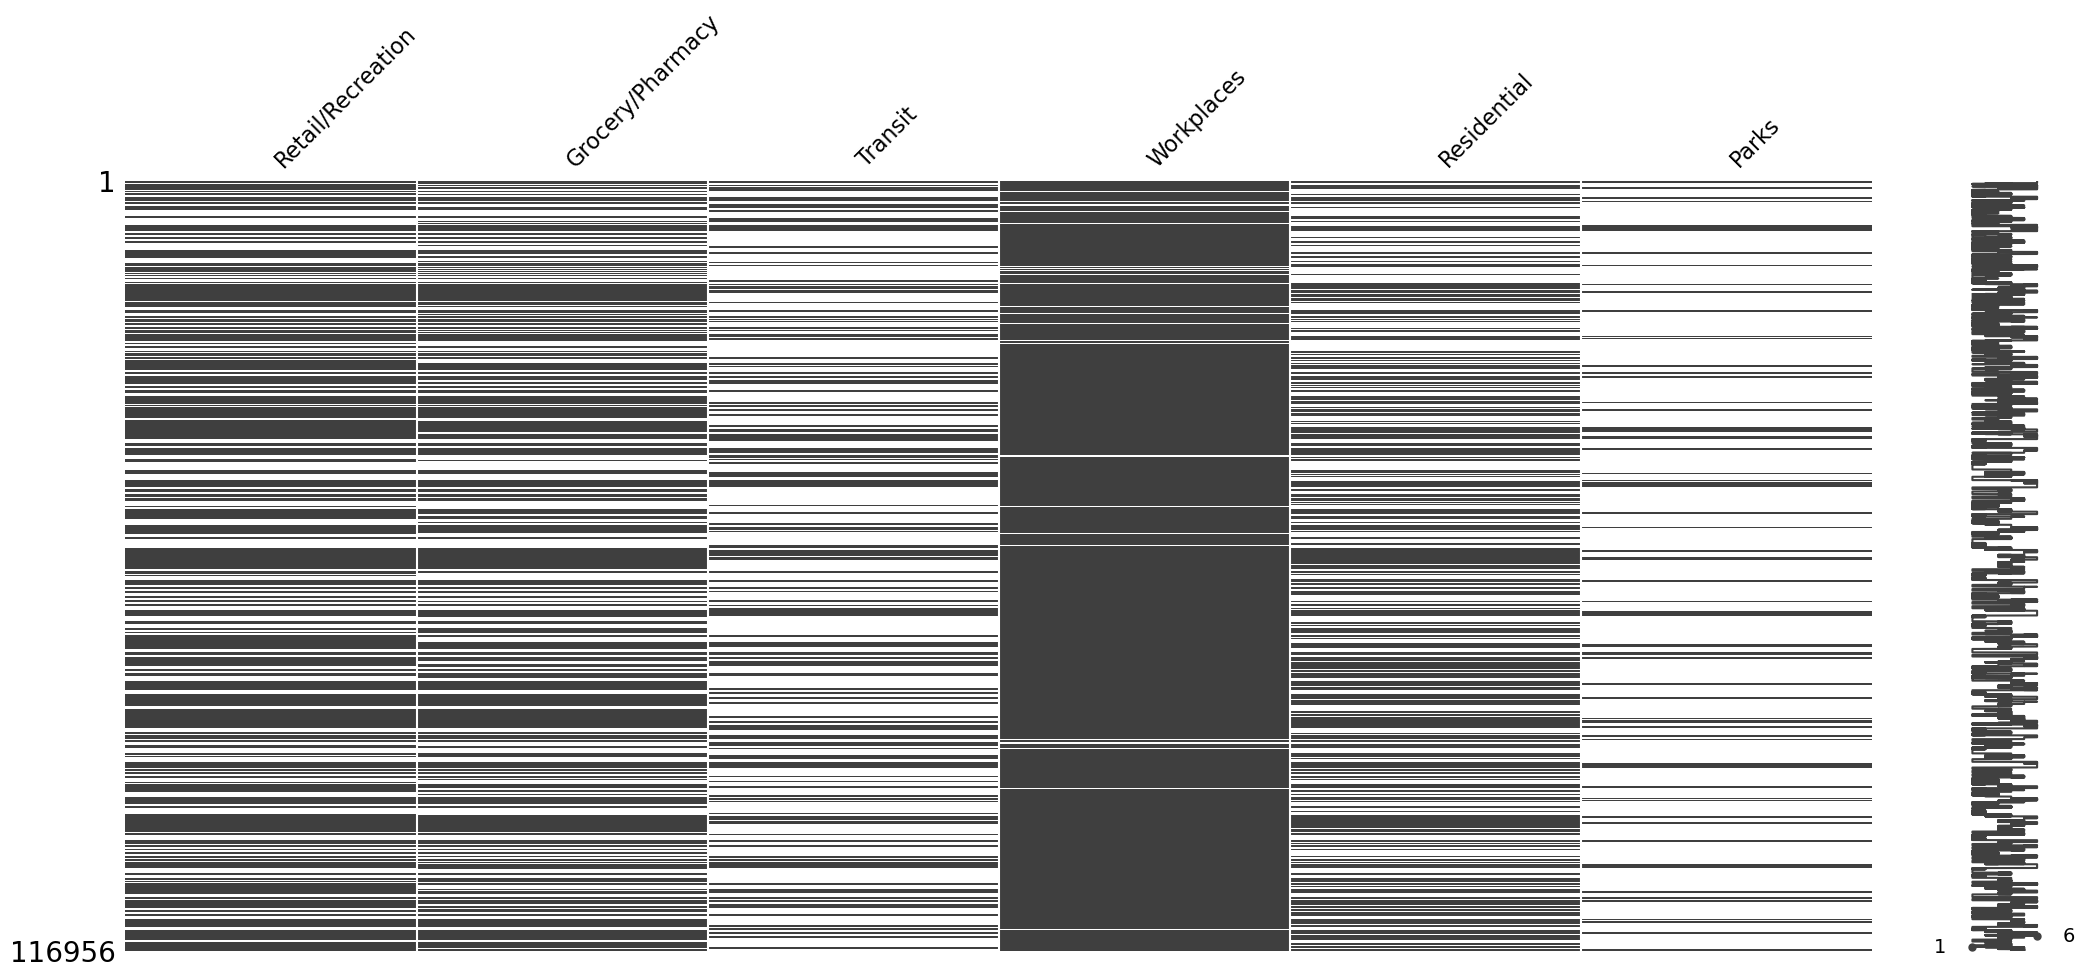

In [ ]:
mobility_og.rename(columns={
    'retail_and_recreation_percent_change_from_baseline':'Retail/Recreation', 
    'grocery_and_pharmacy_percent_change_from_baseline':'Grocery/Pharmacy',
    'transit_stations_percent_change_from_baseline':'Transit',
    'workplaces_percent_change_from_baseline':'Workplaces',
    'residential_percent_change_from_baseline':'Residential', 
    'parks_percent_change_from_baseline':'Parks'
}, inplace=True)

short_feats=['Retail/Recreation', 'Grocery/Pharmacy', 'Transit', 'Workplaces', 'Residential', 'Parks']
msno.matrix(mobility_og[short_feats])

In [ ]:
# summary stats
described = pd.DataFrame(mobility[feats].describe().T)
described = described.rename(columns={'50%': 'median'})  # fix rename
described = round(described, 2)
display(described)

# LaTeX export
latex_table = described.to_latex(float_format="%.2f", index=True)
print("\\begin{table}[ht]\n\\centering")
print(latex_table)
print("\\caption{Descriptive statistics for mobility features.}")
print("\\label{tab:mobility_descriptives}")
print("\\end{table}")

,count,mean,std,min,25%,median,75%,max
retail_and_recreation_percent_change_from_baseline,33013.0,-11.51,16.59,-95.0,-20.0,-11.0,-2.0,114.0
grocery_and_pharmacy_percent_change_from_baseline,33013.0,0.69,14.39,-92.0,-8.0,0.0,8.0,100.0
transit_stations_percent_change_from_baseline,33013.0,-19.09,33.18,-86.0,-44.0,-22.0,0.0,246.0
workplaces_percent_change_from_baseline,33013.0,-26.48,16.38,-91.0,-37.0,-26.0,-15.0,18.0
residential_percent_change_from_baseline,33013.0,7.72,5.99,-5.0,4.0,7.0,11.0,40.0


\begin{table}[ht]
\centering
\begin{tabular}{lrrrrrrrr}
\toprule
 & count & mean & std & min & 25% & median & 75% & max \\
\midrule
retail_and_recreation_percent_change_from_baseline & 33013.00 & -11.51 & 16.59 & -95.00 & -20.00 & -11.00 & -2.00 & 114.00 \\
grocery_and_pharmacy_percent_change_from_baseline & 33013.00 & 0.69 & 14.39 & -92.00 & -8.00 & 0.00 & 8.00 & 100.00 \\
transit_stations_percent_change_from_baseline & 33013.00 & -19.09 & 33.18 & -86.00 & -44.00 & -22.00 & 0.00 & 246.00 \\
workplaces_percent_change_from_baseline & 33013.00 & -26.48 & 16.38 & -91.00 & -37.00 & -26.00 & -15.00 & 18.00 \\
residential_percent_change_from_baseline & 33013.00 & 7.72 & 5.99 & -5.00 & 4.00 & 7.00 & 11.00 & 40.00 \\
\bottomrule
\end{tabular}

\caption{Descriptive statistics for mobility features.}
\label{tab:mobility_descriptives}
\end{table}


In [ ]:
import pandas as pd

# features you care about
feats = [
    "retail_and_recreation_percent_change_from_baseline",
    "grocery_and_pharmacy_percent_change_from_baseline",
    "transit_stations_percent_change_from_baseline",
    "workplaces_percent_change_from_baseline",
    "residential_percent_change_from_baseline"
]

# Abbreviate long feature names for table readability
feature_map = {
    "retail_and_recreation_percent_change_from_baseline": "Retail/Rec",
    "grocery_and_pharmacy_percent_change_from_baseline": "Grocery/Pharm",
    "transit_stations_percent_change_from_baseline": "Transit",
    "workplaces_percent_change_from_baseline": "Workplaces",
    "residential_percent_change_from_baseline": "Residential"
}

# Compute only the key statistics: mean, std, median, Q1, Q3
described = mobility[feats].agg(['mean', 'std', 'median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
described = described.rename(index={'<lambda_0>':'Q1','<lambda_1>':'Q3'})  # rename lambda columns
described = described.round(2)  # round to 2 decimals
described.index = ['Mean', 'Std', 'Median', 'Q1', 'Q3']  # nicer index labels

# Transpose so rows = features, columns = stats
described = described.T
described.index = described.index.map(feature_map)

latex_table = described.to_latex(
    float_format="%.2f",
    index=True,
    caption="Key descriptive statistics for mobility features.",
    label="tab:key_stats",
)

print(latex_table)

\begin{table}
\caption{Key descriptive statistics for mobility features.}
\label{tab:key_stats}
\begin{tabular}{lrrrrr}
\toprule
 & Mean & Std & Median & Q1 & Q3 \\
\midrule
Retail/Rec & -11.51 & 16.59 & -11.00 & -20.00 & -2.00 \\
Grocery/Pharm & 0.69 & 14.39 & 0.00 & -8.00 & 8.00 \\
Transit & -19.09 & 33.18 & -22.00 & -44.00 & 0.00 \\
Workplaces & -26.48 & 16.38 & -26.00 & -37.00 & -15.00 \\
Residential & 7.72 & 5.99 & 7.00 & 4.00 & 11.00 \\
\bottomrule
\end{tabular}
\end{table}



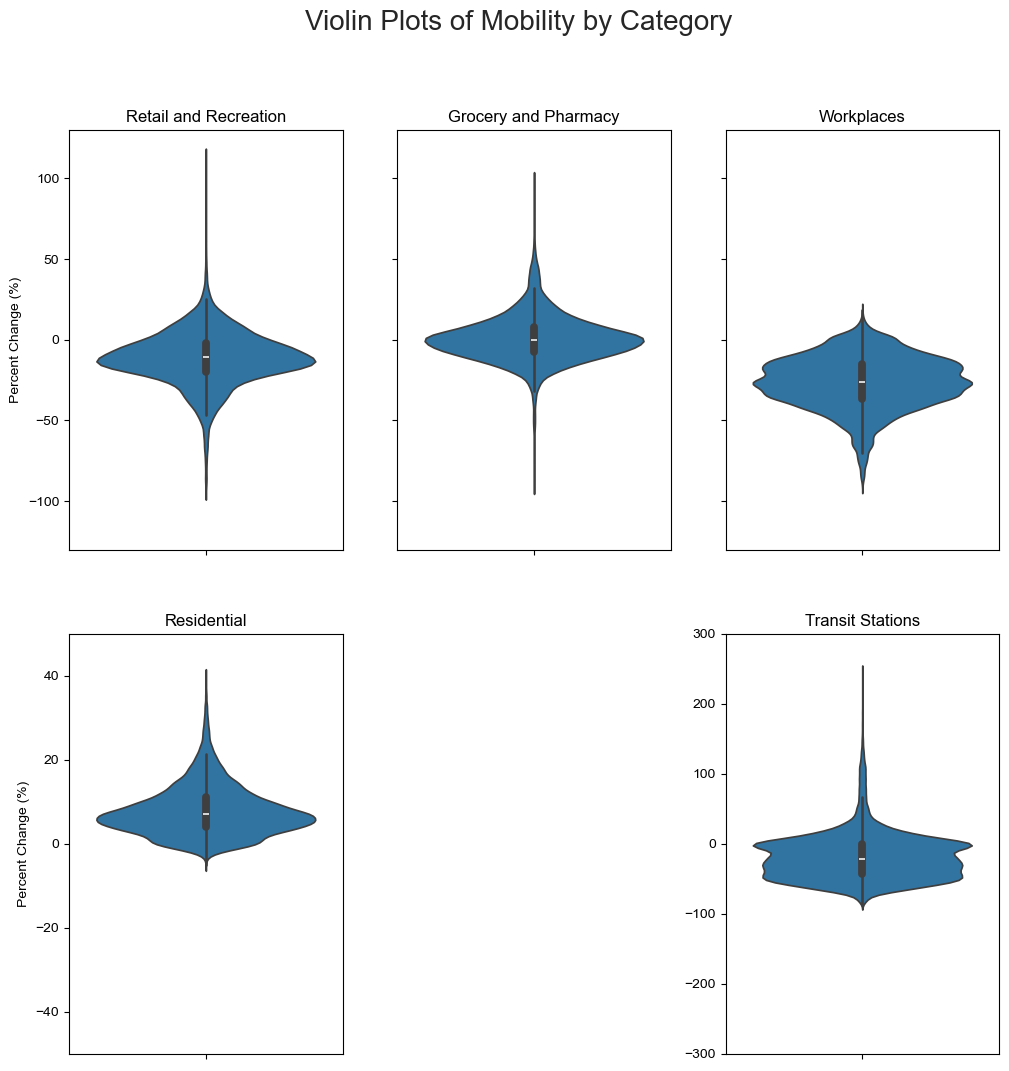

In [ ]:


# violin plots

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 12))

sns.set_style("darkgrid")

sns.violinplot(y=mobility["retail_and_recreation_percent_change_from_baseline"], ax=axes[0, 0])
sns.violinplot(y=mobility["grocery_and_pharmacy_percent_change_from_baseline"], ax=axes[0, 1])
sns.violinplot(y=mobility["transit_stations_percent_change_from_baseline"], ax=axes[1, 2])
sns.violinplot(y=mobility["workplaces_percent_change_from_baseline"], ax=axes[0, 2])
sns.violinplot(y=mobility["residential_percent_change_from_baseline"], ax=axes[1, 0])

for ax in [axes[0, 0], axes[1, 0]]: 
    ax.set_ylabel("Percent Change (%)")

for ax in [axes[0, 1], axes[0, 2]]: 
    ax.set_ylabel('')
    ax.set_yticklabels([])

for ax in axes.flatten(): 
    ax.set_ylim(-130, 130)

axes[1, 2].set_ylim(-300, 300)
axes[1, 2].set_ylabel('')

axes[1, 0].set_ylim(-50, 50)

axes[0, 0].set_title("Retail and Recreation")
axes[0, 1].set_title("Grocery and Pharmacy")
axes[1, 2].set_title("Transit Stations")
axes[0, 2].set_title("Workplaces")
axes[1, 0].set_title("Residential")

fig.suptitle("Violin Plots of Mobility by Category", fontsize=20)

fig.delaxes(axes[1, 1])

## Filtering

In [ ]:
import pandas as pd
from pathlib import Path

va_mobility = pd.read_csv('/Users/savannahdrake/Desktop/JMU/MATH 250/va_mobility.csv')

path_od = Path('/Users/savannahdrake/Desktop/JMU/MATH 250')

mobility_og_2020 = pd.read_csv(path_od/"2020_US_Region_Mobility_Report.csv")
mobility_og_2021 = pd.read_csv(path_od/"2021_US_Region_Mobility_Report.csv")
mobility_og_2022 = pd.read_csv(path_od/"2022_US_Region_Mobility_Report.csv")

mobility_og = pd.concat([mobility_og_2020, mobility_og_2021, mobility_og_2022], axis=0, ignore_index=True)

print(f"og mobility: {mobility_og.shape}")

og mobility: (2511994, 15)


In [ ]:
pd.to_datetime(mobility_og['date'])
print(mobility_og['date'].min())
print(mobility_og['date'].max())

2020-02-15
2022-10-15


In [ ]:
# filter for VA
mobility_va = mobility_og[mobility_og['sub_region_1']=="Virginia"]

print(f"va mobility: {va_mobility.shape}")

print(f"\nmobility va: {mobility_va.shape}")

mobility_va.to_csv('/Users/savannahdrake/Desktop/JMU/MATH 250/mobility_va.csv')

va mobility: (157834, 15)

mobility va: (116956, 15)


In [ ]:
print(mobility_va['date'].min())
print(mobility_va['date'].max())

2020-02-15
2022-10-15


## NA Handling

In [ ]:
import pandas as pd
import numpy as np


mobility = pd.read_csv('/Users/savannahdrake/Desktop/JMU/MATH 250/mobility_va.csv')
mobility['date'] = pd.to_datetime(mobility['date'])

na_ratio = mobility.isna().mean()
print(na_ratio)

features = [
    'retail_and_recreation_percent_change_from_baseline', 
    'grocery_and_pharmacy_percent_change_from_baseline', 
    'parks_percent_change_from_baseline', 
    'transit_stations_percent_change_from_baseline', 
    'workplaces_percent_change_from_baseline', 
    'residential_percent_change_from_baseline'
]

rural_counties = ["Accomack County","Alleghany County","Bath County",
                  "Bland County","Brunswick County","Buchanan County",
                  "Carroll County","Charlotte County","Craig County",
                  "Dickenson County","Essex County","Grayson County",
                  "Greensville County","Halifax County","Henry County",
                  "Highland County","Lee County","Louisa County",
                  "Lunenburg County","Madison County","Mecklenburg County",
                  "Middlesex County","Montgomery County","Nelson County",
                  "Northampton County","Northumberland County","Patrick County",
                  "Pittsylvania County","Prince Edward County","Pulaski County",
                  "Richmond County","Rockbridge County","Rockingham County",
                  "Russell County","Smyth County","Southampton County",
                  "Tazewell County","Wise County","Wythe County","Shenandoah County"]

mobility['metro_label'] = np.where(mobility['sub_region_2'].isin(rural_counties), 0, 1)

Unnamed: 0                                            0.000000
country_region_code                                   0.000000
country_region                                        0.000000
sub_region_1                                          0.000000
sub_region_2                                          0.008328
metro_area                                            1.000000
iso_3166_2_code                                       0.991672
census_fips_code                                      0.008328
place_id                                              0.000000
date                                                  0.000000
retail_and_recreation_percent_change_from_baseline    0.366582
grocery_and_pharmacy_percent_change_from_baseline     0.402049
parks_percent_change_from_baseline                    0.844950
transit_stations_percent_change_from_baseline         0.645858
workplaces_percent_change_from_baseline               0.032072
residential_percent_change_from_baseline              0

/var/folders/_0/52ky82_s0v3g_g6jnmhqrykm0000gn/T/ipykernel_2623/2632527937.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  mobility = pd.read_csv('/Users/savannahdrake/Desktop/JMU/MATH 250/mobility_va.csv')


In [ ]:
features_keep = [f for f in features if mobility[f].notna().mean() > 0.3]

print("Keeping features:", features_keep)

Keeping features: ['retail_and_recreation_percent_change_from_baseline', 'grocery_and_pharmacy_percent_change_from_baseline', 'transit_stations_percent_change_from_baseline', 'workplaces_percent_change_from_baseline', 'residential_percent_change_from_baseline']


In [ ]:
county_max_missing = (
    mobility
    .groupby('sub_region_2')[features_keep]
    .apply(lambda df: df.isna().mean().max())
)
counties_keep = county_max_missing[county_max_missing < 0.5].index

mobility_counties_filtered = mobility[mobility['sub_region_2'].isin(counties_keep)]

In [ ]:
mobility_clean = (
    mobility_counties_filtered
    .sort_values(['sub_region_2', 'date'])
    .groupby('sub_region_2', group_keys=False)
    .apply(lambda df: df[features_keep].interpolate(limit_direction='both')
                          .ffill()
                          .bfill()
                          .assign(metro_label=df['metro_label'], date=df['date'], sub_region_2=df['sub_region_2']))
)

/var/folders/_0/52ky82_s0v3g_g6jnmhqrykm0000gn/T/ipykernel_2623/591618370.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df[features_keep].interpolate(limit_direction='both')


In [ ]:
print(mobility_clean.shape)
print(mobility_clean['date'].min())
print(mobility_clean['date'].max())

(33013, 8)
2020-02-15 00:00:00
2022-10-15 00:00:00


In [ ]:
monthly = pd.read_csv('/Users/savannahdrake/Desktop/JMU/MATH 250/monthly.csv')
print(monthly.size)

14586


In [ ]:
print(len(mobility_clean['sub_region_2'].unique()))
print(mobility_clean[:].isna().sum())

print(mobility_clean['metro_label'].sum()/len(mobility_clean))

mobility_clean.to_csv('/Users/savannahdrake/Desktop/JMU/MATH 250/mobility_clean.csv', index=False)

34
retail_and_recreation_percent_change_from_baseline    0
grocery_and_pharmacy_percent_change_from_baseline     0
transit_stations_percent_change_from_baseline         0
workplaces_percent_change_from_baseline               0
residential_percent_change_from_baseline              0
metro_label                                           0
date                                                  0
sub_region_2                                          0
dtype: int64
0.8541180746978463


In [ ]:
mobility_1 = mobility_clean.copy()
mobility_1["year_month"] = mobility_1["date"].dt.to_period('M')

monthly = mobility_1.groupby("year_month")[features_keep].mean()
monthly.to_csv('/Users/savannahdrake/Desktop/JMU/MATH 250/monthly.csv')

## PCA

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

mobility = pd.read_csv('/Users/savannahdrake/Desktop/JMU/MATH 250/mobility_clean.csv')
mobility['date'] = pd.to_datetime(mobility['date'])
mobility["year_month"] = mobility["date"].dt.to_period('M')

monthly = mobility.groupby(['sub_region_2', 'year_month']).mean().reset_index()

# mobility columns
mobility_feats = [
    'retail_and_recreation_percent_change_from_baseline', 
    'grocery_and_pharmacy_percent_change_from_baseline', 
    'transit_stations_percent_change_from_baseline', 
    'workplaces_percent_change_from_baseline', 
    'residential_percent_change_from_baseline'
]


rural_counties = ["Accomack County","Alleghany County","Bath County",
                  "Bland County","Brunswick County","Buchanan County",
                  "Carroll County","Charlotte County","Craig County",
                  "Dickenson County","Essex County","Grayson County",
                  "Greensville County","Halifax County","Henry County",
                  "Highland County","Lee County","Louisa County",
                  "Lunenburg County","Madison County","Mecklenburg County",
                  "Middlesex County","Montgomery County","Nelson County",
                  "Northampton County","Northumberland County","Patrick County",
                  "Pittsylvania County","Prince Edward County","Pulaski County",
                  "Richmond County","Rockbridge County","Rockingham County",
                  "Russell County","Smyth County","Southampton County",
                  "Tazewell County","Wise County","Wythe County","Shenandoah County"]

mobility['metro_label'] = np.where(mobility['sub_region_2'].isin(rural_counties), 0, 1)
monthly['metro_label'] = np.where(monthly['sub_region_2'].isin(rural_counties), 0, 1)

monthly.to_csv('/Users/savannahdrake/Desktop/JMU/MATH 250/monthly.csv')

# checkna
mobility_pca = mobility[mobility_feats]
monthly_pca = monthly[mobility_feats]

print(mobility_pca.isna().sum())
print(monthly_pca.isna().sum())

retail_and_recreation_percent_change_from_baseline    0
grocery_and_pharmacy_percent_change_from_baseline     0
transit_stations_percent_change_from_baseline         0
workplaces_percent_change_from_baseline               0
residential_percent_change_from_baseline              0
dtype: int64
retail_and_recreation_percent_change_from_baseline    0
grocery_and_pharmacy_percent_change_from_baseline     0
transit_stations_percent_change_from_baseline         0
workplaces_percent_change_from_baseline               0
residential_percent_change_from_baseline              0
dtype: int64


#### Justify assumptions (only some, rest in Github under pca_assumptions ran by Rory

In [ ]:
short_names = {
    'retail_and_recreation_percent_change_from_baseline': 'Retail/Recreation',
    'grocery_and_pharmacy_percent_change_from_baseline': 'Grocery/Pharmacy',
    'transit_stations_percent_change_from_baseline': 'Transit Stations',
    'workplaces_percent_change_from_baseline': 'Workplaces',
    'residential_percent_change_from_baseline': 'Residential'
}

monthly = monthly.rename(columns=short_names)

mobility_feats_short = ['Retail/Recreation', 'Grocery/Pharmacy', 'Transit Stations', 'Workplaces', 'Residential']

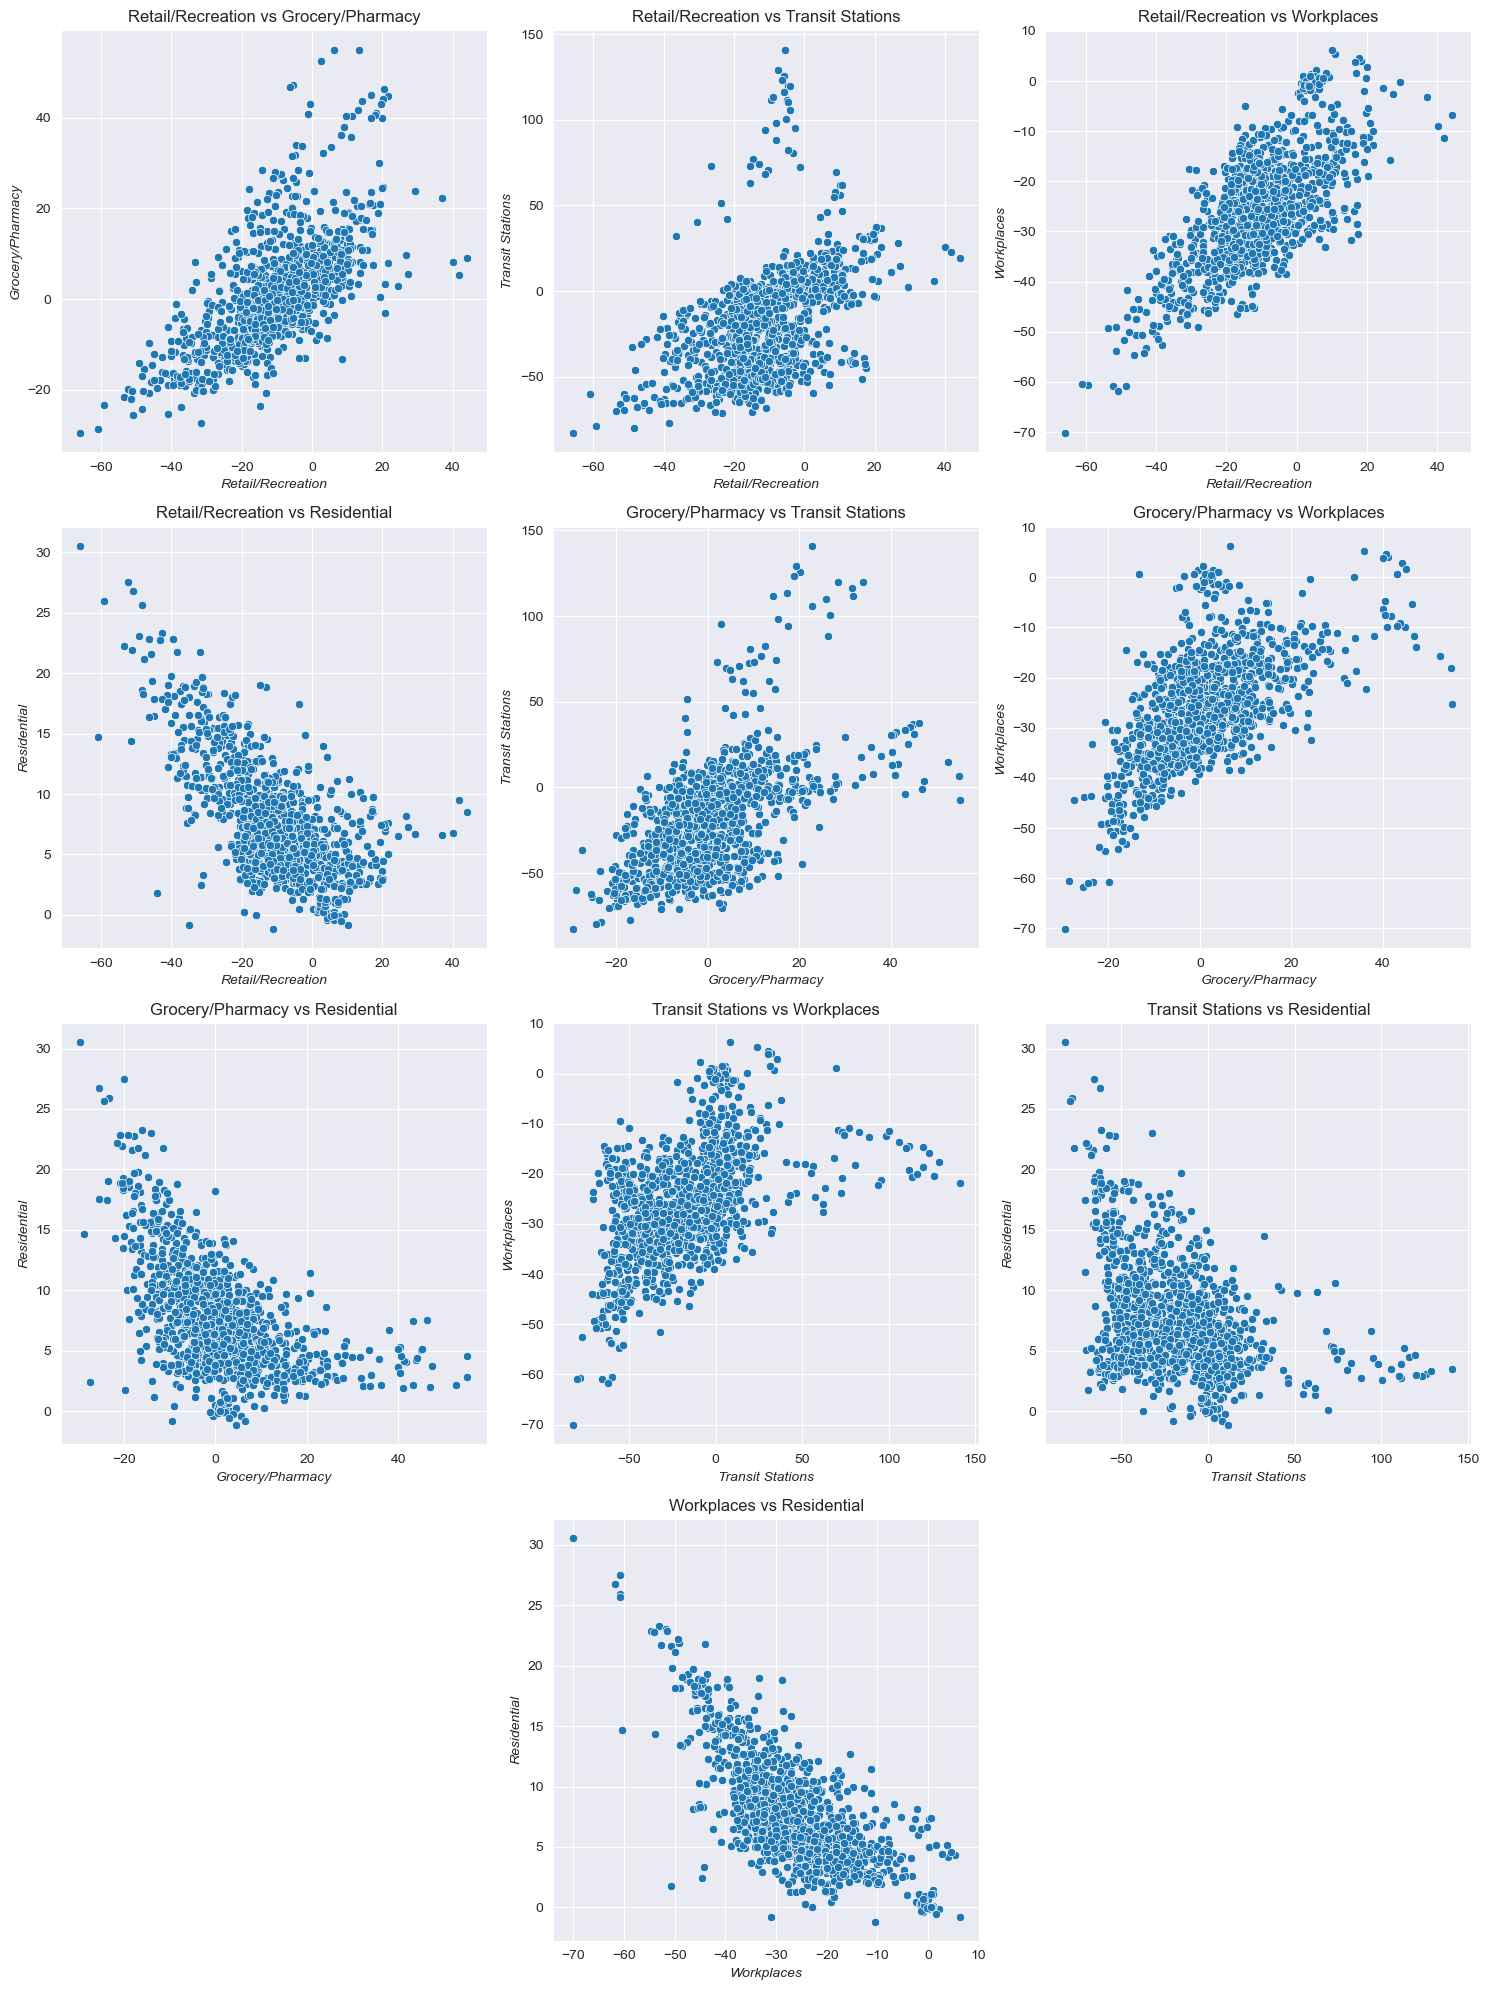

In [ ]:
# linearity: scatterplots
import itertools

pairs = list(itertools.combinations(mobility_feats_short, 2))

fig, axes = plt.subplots(4, 3, figsize=(15, 20))
axes = axes.flatten()

for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(data=monthly, x=x, y=y, ax=ax)
    ax.set_xlabel(x, style='italic')
    ax.set_ylabel(y, style='italic')
    ax.set_title(f"{x} vs {y}")

x_last, y_last = pairs[-1]

sns.scatterplot(data=monthly, x=x_last, y=y_last, ax=axes[10])
axes[10].set_title(f"{x_last} vs {y_last}")
axes[10].set_xlabel(x_last, style='italic')
axes[10].set_ylabel(y_last, style='italic')

# hide unused axes: 9 and 11
axes[9].set_visible(False)
axes[11].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
print(monthly.columns)

Index(['sub_region_2', 'year_month', 'Retail/Recreation', 'Grocery/Pharmacy',
       'Transit Stations', 'Workplaces', 'Residential', 'metro_label', 'date'],
      dtype='object')


In [ ]:
# scale data
scaler = StandardScaler()
mob_scaled = scaler.fit_transform(mobility_pca)

# pca
pca = PCA(n_components=2)
pca_result = pca.fit_transform(mob_scaled)

mobility['PC1'] = pca_result[:,0]
mobility['PC2'] = pca_result[:,1]

print(pca.explained_variance_ratio_)  # How much variance is captured

[0.60836152 0.16625265]


In [ ]:
# scale data
scaler = StandardScaler()
monthly_scaled = scaler.fit_transform(monthly_pca)

pca_m = PCA(n_components=2)
monthly_result = pca_m.fit_transform(monthly_scaled)

monthly['PC1'] = monthly_result[:,0]
monthly['PC2'] = monthly_result[:,1]
print(pca_m.explained_variance_ratio_)

[0.67180184 0.13591872]


In [ ]:
print(monthly.size)

12342


Text(0, 0.5, 'PC2')

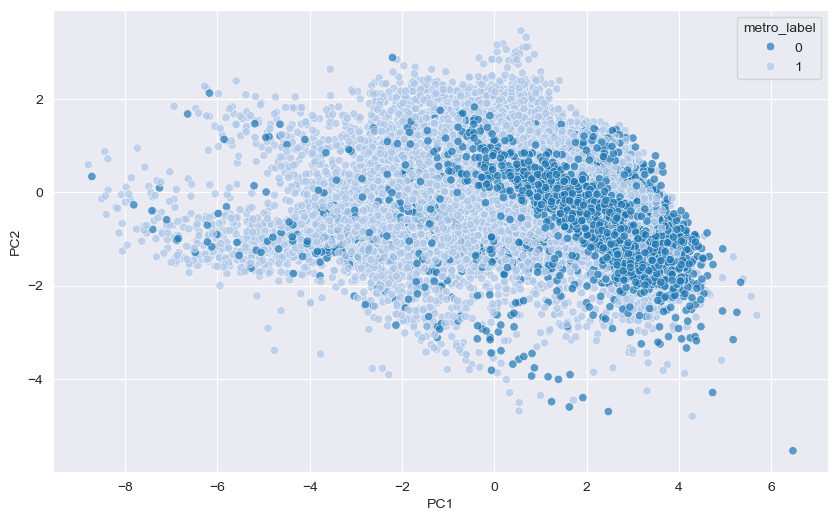

In [ ]:
# visualize
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='metro_label', 
    data=mobility, 
    alpha=0.7,
    palette='tab20',
    legend=True
)
plt.xlabel("PC1")
plt.ylabel("PC2")

Text(0, 0.5, 'PC2')

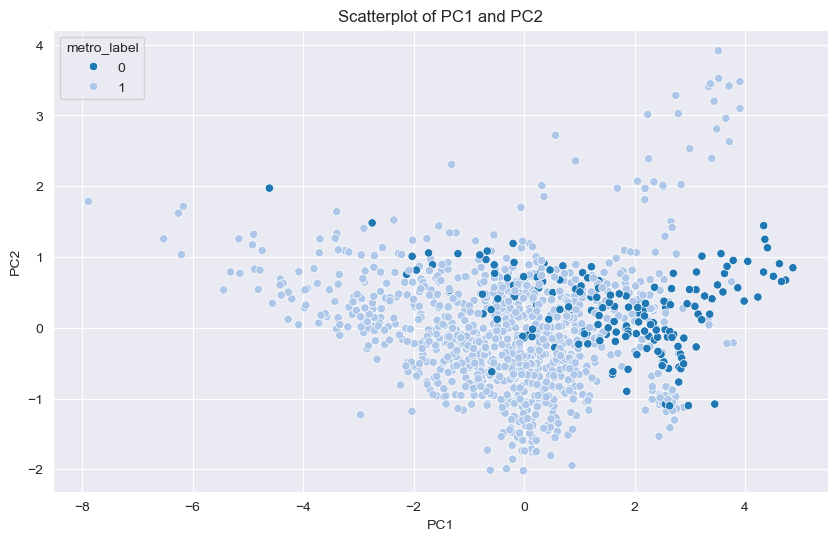

In [ ]:
# visualize
plt.figure(figsize=(10, 6))
sns.set_style(style="darkgrid")
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='metro_label', 
    data=monthly, 
    palette='tab20',
    legend=True
)
plt.title("Scatterplot of PC1 and PC2")

plt.xlabel("PC1")
plt.ylabel("PC2")

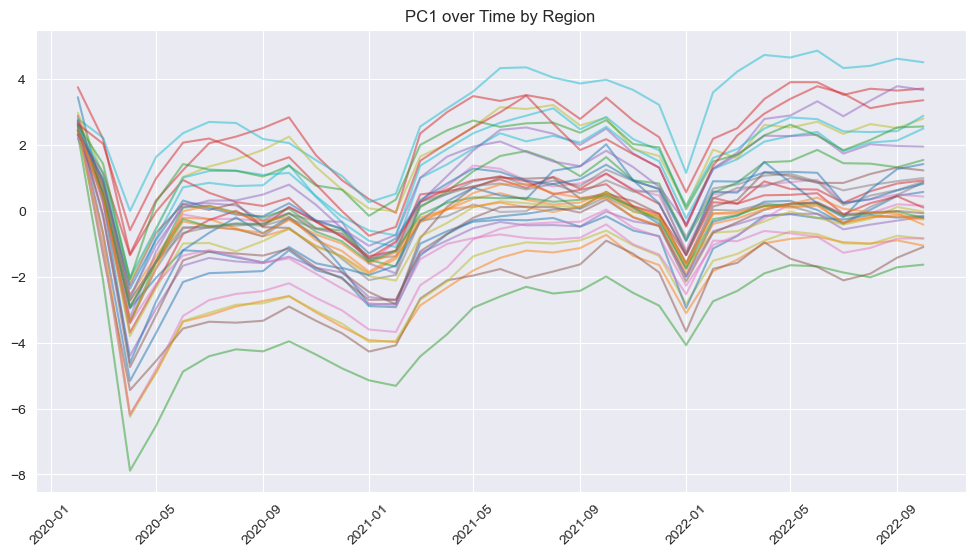

In [ ]:
monthly['year_month_dt'] = monthly['year_month'].dt.to_timestamp()

plt.figure(figsize=(12,6))
for region, group in monthly.groupby('sub_region_2'):
    plt.plot(group['year_month_dt'], group['PC1'], alpha=0.5)
plt.xticks(rotation=45)
plt.title('PC1 over Time by Region')
plt.show()

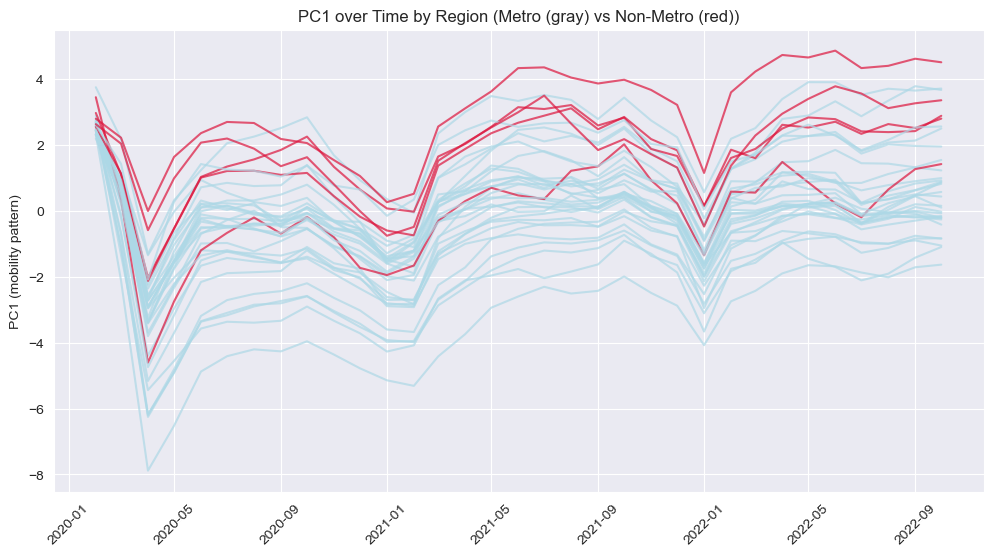

In [ ]:
plt.figure(figsize=(12,6))

# Plot each region, coloring by metro status
for (region, metro_label), group in monthly.groupby(['sub_region_2','metro_label']):
    if metro_label == 1:  # Metro
        plt.plot(group['year_month_dt'], group['PC1'], color='lightblue', alpha=0.7)
    else:  # Non-metro
        plt.plot(group['year_month_dt'], group['PC1'], color='crimson', alpha=0.7)

plt.xticks(rotation=45)
plt.ylabel('PC1 (mobility pattern)')
plt.title('PC1 over Time by Region (Metro (gray) vs Non-Metro (red))')
plt.show()

In [ ]:
mob_feats_short = ["retail/rec", "grocery/pharma", "transit", "workplaces", "residential"]
loadings = pd.DataFrame(pca_m.components_.T, 
                        index=mob_feats_short,  # your original categories
                        columns=[f'PC{i+1}' for i in range(len(pca.components_))])


print(loadings['PC1'])

retail/rec        0.469539
grocery/pharma    0.454356
transit           0.379140
workplaces        0.476763
residential      -0.449492
Name: PC1, dtype: float64


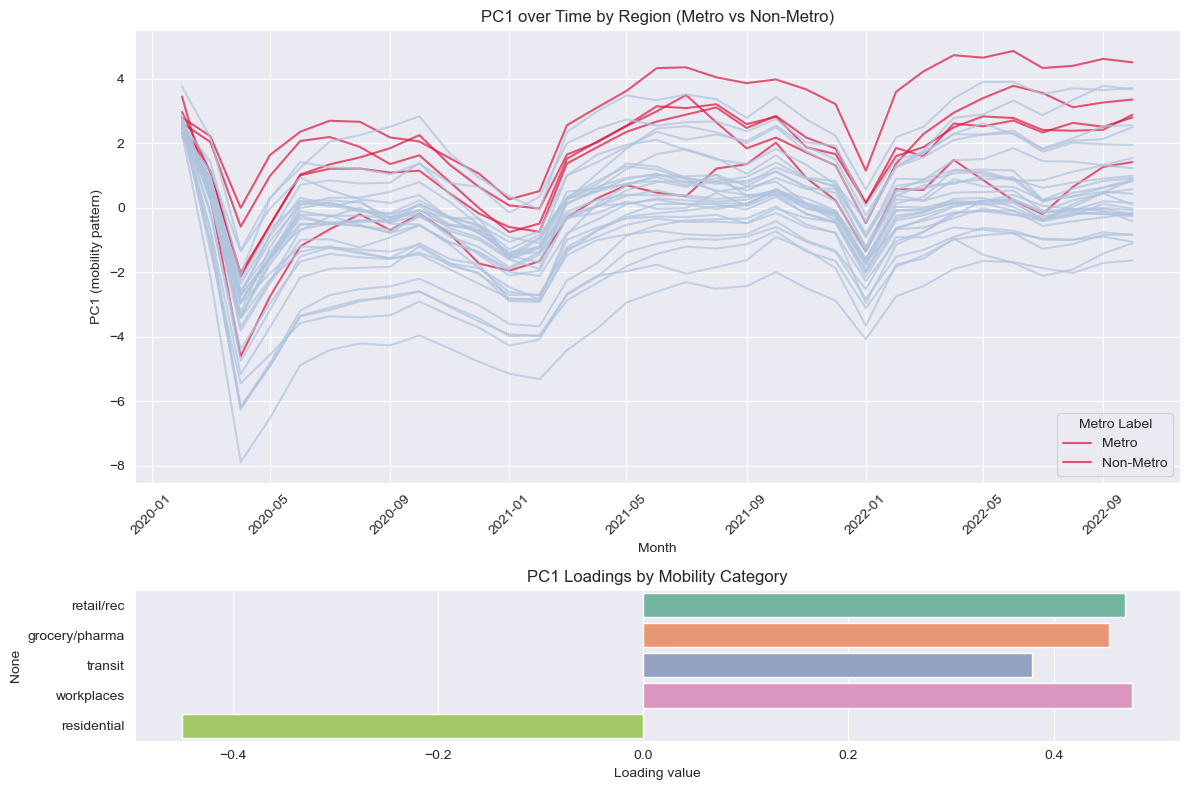

In [ ]:
short_names = {
    'retail_and_recreation_percent_change_from_baseline': 'Retail/Recreation',
    'grocery_and_pharmacy_percent_change_from_baseline': 'Grocery/Pharmacy',
    'transit_stations_percent_change_from_baseline': 'Transit Stations',
    'workplaces_percent_change_from_baseline': 'Workplaces',
    'residential_percent_change_from_baseline': 'Residential'
}
loadings_short = loadings.rename(index=short_names)

monthly['year_month_dt'] = monthly['year_month'].dt.to_timestamp()

# fig with 2 subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

# top: pc1 over time
ax = axes[0]
sns.set_style(style="darkgrid")
sns.lineplot(
    data=monthly,
    x='year_month_dt',
    y='PC1',
    hue='metro_label',  # 1=Metro, 0=Rural
    units='sub_region_2',
    estimator=None,
    palette={0: 'crimson', 1: 'lightsteelblue'},
    alpha=0.7,
    ax=ax,
    legend='full'
)

ax.set_ylabel('PC1 (mobility pattern)')
ax.set_xlabel("Month")
ax.set_title('PC1 over Time by Region (Metro vs Non-Metro)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Metro Label', labels=['Metro', 'Non-Metro'])

# --- Bottom subplot: PC1 loadings ---
ax2 = axes[1]
sns.set_style(style="darkgrid")
sns.barplot(
    x=loadings_short['PC1'].values,
    y=loadings_short['PC1'].index,
    hue=loadings_short['PC1'].index,
    palette='Set2',
    legend=False,
    ax=ax2
)
ax2.set_xlabel('Loading value')
ax2.set_title('PC1 Loadings by Mobility Category')

plt.tight_layout()
plt.show()

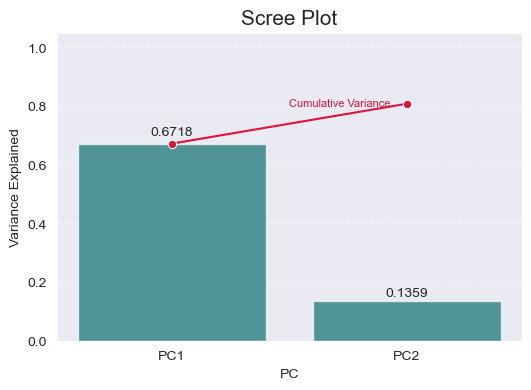

In [ ]:
# prep variance explained
expl_var = pca_m.explained_variance_ratio_
cum_var = np.cumsum(expl_var)

# Make a DataFrame for plotting
scree_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(expl_var))],
    'Variance': expl_var,
    'Cumulative': cum_var
})

plt.figure(figsize=(6,4))

# Barplot for individual variance
sns.set_style(style="darkgrid")
sns.barplot(x='PC', y='Variance', data=scree_df, color='teal', alpha=0.7)

# Lineplot for cumulative variance
sns.lineplot(x='PC', y='Cumulative', data=scree_df, marker='o', color='crimson')
plt.text(x=0.5, y=0.8, s="Cumulative Variance", color="crimson", fontsize=8)
plt.ylabel('Variance Explained')
plt.title('Scree Plot', fontsize=15)
plt.ylim(0,1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.text(-0.09, 0.7, s=f"{pca_m.explained_variance_ratio_[0]:.4f}")
plt.text(0.91, 0.15, s=f"{pca_m.explained_variance_ratio_[1]:.4f}")
plt.show()

/var/folders/_0/52ky82_s0v3g_g6jnmhqrykm0000gn/T/ipykernel_2623/57042018.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.arrow(0, 0, loadings.PC1[i]*3, loadings.PC2[i]*3,
/var/folders/_0/52ky82_s0v3g_g6jnmhqrykm0000gn/T/ipykernel_2623/57042018.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(loadings.PC1[i]*3.3, loadings.PC2[i]*3.3, loadings.index[i],


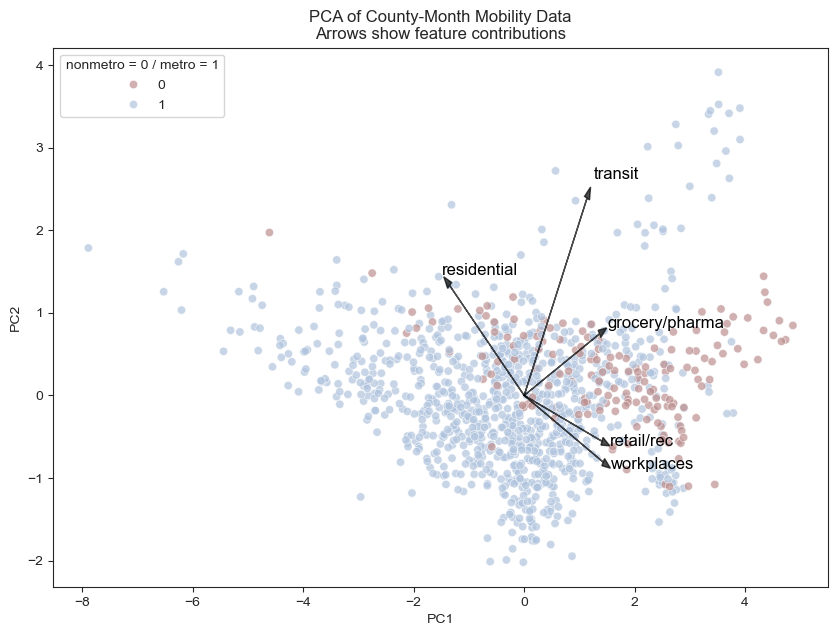

In [ ]:
sns.set_style("ticks")
plt.figure(figsize=(10, 7))
cols = ["rosybrown", "lightsteelblue"]

sns.scatterplot(
    x='PC1', y='PC2', 
    hue='metro_label', palette=cols, 
    data=monthly, 
    alpha=0.7
)

for i in range(loadings.shape[0]): 
    plt.arrow(0, 0, loadings.PC1[i]*3, loadings.PC2[i]*3, 
              color='black', alpha=0.7, head_width=0.1)
    plt.text(loadings.PC1[i]*3.3, loadings.PC2[i]*3.3, loadings.index[i], 
             color='black', fontsize=12)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of County-Month Mobility Data\nArrows show feature contributions')
plt.legend(title='nonmetro = 0 / metro = 1')
plt.show()

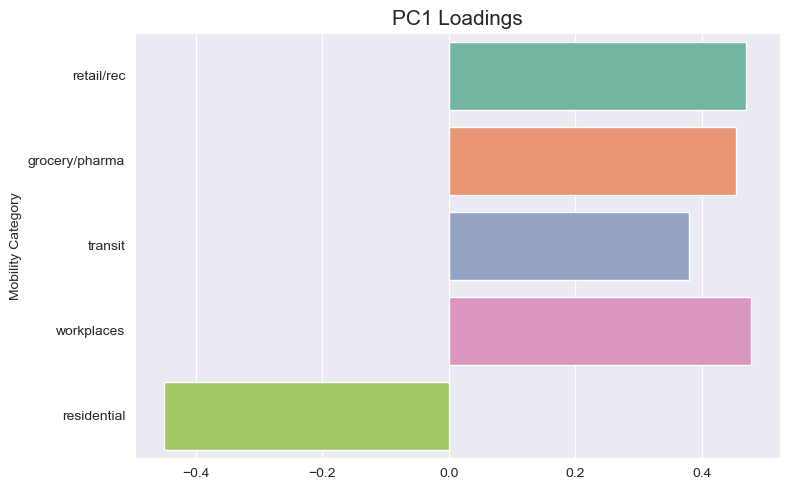

In [ ]:
plt.figure(figsize=(8, 5))
sns.set_style(style="darkgrid")
sns.barplot(
    x=loadings['PC1'].values,
    y=loadings['PC1'].index,
    hue=loadings['PC1'].index,
    palette='Set2',
    legend=False
)
ax2.set_xlabel('Loading value')
ax2.set_title('PC1 Loadings by Mobility Category')
plt.ylabel("Mobility Category")
plt.title("PC1 Loadings", fontsize=15)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
monthly.to_csv('/Users/savannahdrake/Desktop/JMU/MATH 250/monthly.csv')

## Permutation Test by County

In [ ]:
# data and libraries

import numpy as np
import pandas as pd

monthly = pd.read_csv('/Users/savannahdrake/Desktop/JMU/MATH 250/monthly.csv')


In [6]:
#Aggregate: Calculate the mean PC1 for each county
county_means = monthly.groupby(['sub_region_2', 'metro_label'])['PC1'].mean().reset_index()

# Defining the funtion

# separate groups
group_m = county_means.loc[county_means['metro_label'] == 1, 'PC1'].to_numpy(dtype=float)
group_nm = county_means.loc[county_means['metro_label'] == 0, 'PC1'].to_numpy(dtype=float)

np.random.seed(42) # seed

def permutation_test(group_a, group_b, num_permutations=10000): 
    """
    Permutation test for average PC1 scores

    Args: 
        group_a: numpy array-like  object with scores for first group
        group_a: numpy array-like  object with scores for second group
        num_permutations (int): number of permutations

    Returns: 
        p-value 
    """
    group_a = np.array(group_a) # convert to groups
    group_b = np.array(group_b)

    n_a = len(group_a)
    combined = np.concatenate((group_a, group_b))
    observed_diff = np.mean(group_a) - np.mean(group_b)

    count = 0

    for _ in range(num_permutations):
        perm = np.random.permutation(combined)
        perm_diff = np.mean(perm[:n_a]) - np.mean(perm[n_a:])
                
        if np.abs(perm_diff) >= np.abs(observed_diff):
            count += 1
                    
    # Include the observed case in the calculation (+1)
    return (count + 1) / (num_permutations + 1)


p_value = permutation_test(group_m, group_nm)
print(p_value)

0.0018998100189981002


In [ ]:
import numpy as np
import pandas as pd

# 1. Aggregate to one value per county (sc) as per guidance
# This ensures we permute county labels, not months
county_means = monthly.groupby(['sub_region_2', 'metro_label'])['PC1'].mean().reset_index()

# 2. Separate into Metro (1) and Non-Metro (0) groups
group_m = county_means.loc[county_means['metro_label'] == 1, 'PC1'].to_numpy(dtype=float)
group_nm = county_means.loc[county_means['metro_label'] == 0, 'PC1'].to_numpy(dtype=float)

def permutation_test_analysis(group_a, group_b, num_permutations=10000):
    n_a = len(group_a)
    combined = np.concatenate((group_a, group_b))
    observed_diff = np.mean(group_a) - np.mean(group_b)

    count = 0
    for _ in range(num_permutations):
        perm = np.random.permutation(combined)
        perm_diff = np.mean(perm[:n_a]) - np.mean(perm[n_a:])
        
        # Two-sided test: comparing absolute differences
        if np.abs(perm_diff) >= np.abs(observed_diff):
            count += 1
            
    # Calculations based on provided formulas
    p_value = (count + 1) / (num_permutations + 1)
    random_pairings_pct = (count / num_permutations) * 100
    
    # Cohen's d calculation
    n_b = len(group_b)
    pooled_sd = np.sqrt(((n_a - 1) * np.var(group_a, ddof=1) + 
                         (n_b - 1) * np.var(group_b, ddof=1)) / (n_a + n_b - 2))
    cohens_d = observed_diff / pooled_sd

    return p_value, random_pairings_pct, cohens_d, observed_diff

# Execute
p_val, rand_pct, d_stat, obs_diff = permutation_test_analysis(group_m, group_nm)

print(f"P-value: {p_val:.5f}")
print(f"Random Pairings Percentage: {rand_pct:.2f}%")
print(f"Cohen's d: {d_stat:.4f}")
print(f"Observed Difference: {obs_diff:.4f}")

P-value: 0.00190
Random Pairings Percentage: 0.18%
Cohen's d: -1.6152
Observed Difference: -1.9307


In [46]:
observed_diff = np.mean(group_m) - np.mean(group_nm)
print(observed_diff)

n_perms = 10000
diffs = np.zeros(n_perms)

all_pc1 = monthly['PC1'].values
metro_i = monthly['metro_label'] == 1
n_metro = sum(metro_i)

for i in range(n_perms): 
    perms = np.random.permutation(all_pc1)

    perm_metro = perms[:n_metro]
    perm_non = perms[n_metro:]

    diffs[i] = np.mean(perm_metro) - np.mean(perm_non)

p_val = np.mean(np.abs(diffs) >= np.abs(observed_diff))
print(p_val)

-1.9307114151201734
0.0


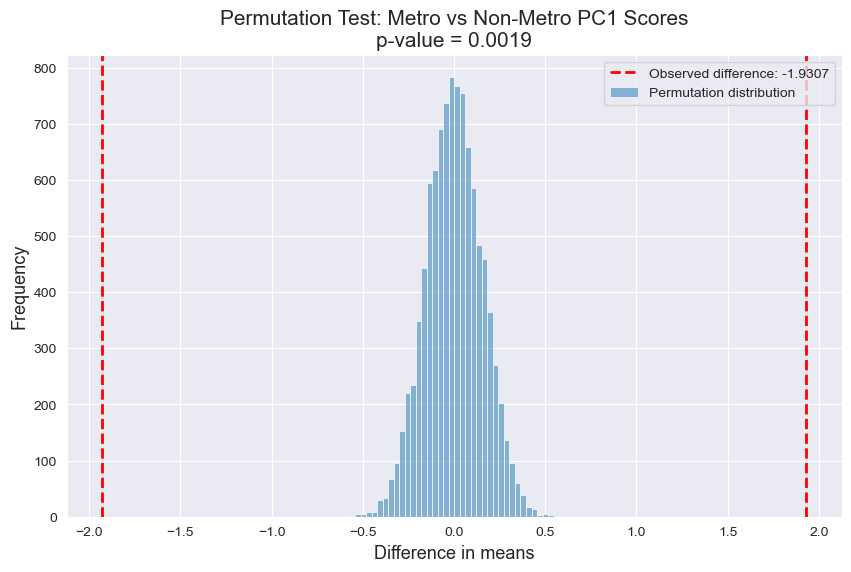

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.figure(figsize=(10, 6))
sns.histplot(diffs, bins=40, alpha=0.5, label='Permutation distribution', 
             linewidth=0.5)
plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2, 
            label=f'Observed difference: {observed_diff:.4f}')

plt.axvline(-observed_diff, color='red', linestyle='dashed', linewidth=2)

plt.title(f'Permutation Test: Metro vs Non-Metro PC1 Scores\np-value = {p_value:.4f}', fontsize=15)
plt.xlabel('Difference in means', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.legend()
plt.show()


### Effect Size of Permutation Test

In [48]:
def calculate_cohens_d(group_a, group_b):
    # Calculate means
    mean_a, mean_b = np.mean(group_a), np.mean(group_b)
    
    # Calculate variances
    n_a, n_b = len(group_a), len(group_b)
    var_a, var_b = np.var(group_a, ddof=1), np.var(group_b, ddof=1)
    
    # Calculate pooled standard deviation
    pooled_sd = np.sqrt(((n_a - 1) * var_a + (n_b - 1) * var_b) / (n_a + n_b - 2))
    
    # Calculate d
    d = (mean_a - mean_b) / pooled_sd
    return d

effect_size = calculate_cohens_d(group_m, group_nm)
print(f"Cohen's d: {effect_size}")

Cohen's d: -1.6151652017468452


In [ ]:
1